In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct
plt.style.use('mplstyle')

In [189]:
# inputs
nua = np.load('nua.npy')
nc = len(nua)
nuc = nua.mean()/1e6
dnuc = abs(nua[1] - nua[0])/1e6
dnu = np.arange(nc)*dnuc

# redshift params
zz = 1420./nuc -1
r, rp = pfunc.rrprime(zz, 'astropy')
fac = r/(rp*nuc) # theoretically predicted FG wedge boundary: kpara_H = fac*kper
dkl = 0. # fixed buffer

# baseline, ell, kper, kpara
Umin, Umax, Nbin = 6, 220, 20
# edges = np.geomspace(Umin, Umax, Nbin + 1)
# UU = np.sqrt(edges[:-1] * edges[1:])
edges = np.linspace(Umin, Umax, Nbin + 1)
UU = 0.5 * (edges[:-1] + edges[1:])

ell = 2*np.pi*UU
print('ell:', ell)
nell = len(ell)

kper = ell/r
print('kper:', kper)

# PS params # should be dynamically chosen based on Cl.shape
nc1 = nc # nc - 2*NN can be chosen
vfac = rp*r*r*dnuc*(nc1-1) # DCT factor
kpara = 2.*np.pi*np.arange(nc1)/(rp*(2.*nc1-2.)*dnuc)
print('kpara:', kpara[1], kpara[-1])
w = windows.nuttall(2*nc1)[nc1:] # window for Fourier transform
wf = windows.nuttall(nc1) # window for Fourier transform of visibilities
# kper = kpara.copy()

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
KK = PK21[:, 0]
PK = PK21[:, 1]

# EoR power spectrum model in high resolution
KK = np.logspace(np.log10(0.001), np.log10(10), 10000)
PK = KK**-2

PKm2D = pfunc.get_model_pk_2d(kper, kpara, KK, PK)

Redshift = 8.206729512407456 
Comoving distance (from astropy): 9209.71452683092 Mpc
rprime (from astropy) = 16.98990953034521 Mpc/MHz
ell: [  71.31415324  138.54423602  205.77431881  273.0044016   340.23448438
  407.46456717  474.69464996  541.92473274  609.15481553  676.38489832
  743.6149811   810.84506389  878.07514668  945.30522947 1012.53531225
 1079.76539504 1146.99547783 1214.22556061 1281.4556434  1348.68572619]
kper: [0.00774336 0.01504327 0.02234318 0.02964309 0.036943   0.04424291
 0.05154282 0.05884273 0.06614264 0.07344255 0.08074246 0.08804237
 0.09534228 0.10264219 0.1099421  0.117242   0.12454191 0.13184182
 0.13914173 0.14644164]
kpara: 0.0060270313587951685 4.622733052195895


In [190]:
flag = pfunc.flagdata(nc, mode='NOFLAG', percent = 10) # RANDOM, MWA, NOFLAG
flag = pfunc.flagdata(nc, mode='NOFLAG', percent = 50) # RANDOM, MWA, NOFLAG

In [191]:
# N = 1024
# k = np.arange(N)
# PKm = (k + 1)**-4.0  # some toy power-law, avoid k=0 divergence

# VX = pfunc.get_vis(PKm, r=1.0, rp=1.0, dnuc=1.0)

# # Estimate output power spectrum from the realisation
# FFT = np.fft.fft(VX)
# est_P = np.abs(FFT)**2  # better: average over many realisations


In [192]:
fact = vfac
ml = pfunc.covtocl_fast(flag, flag) # counter for normalizition 
# ml_norm = abs(np.load('ml_norm.npy'))
# ml = abs(ml_norm[0])


Nrea = 10 # number of realizations

nc1 = nc - 0
nc1 = np.argmax(ml.real == 0) if np.any(ml.real == 0) else nc # only where cl is valid, ie, discarding last few delta nu
kpara1 = 2.*np.pi*np.arange(nc1)/(rp*(2.*nc1-2.)*dnuc)
w = windows.nuttall(2*nc1)[nc1:] # window for Fourier transform
print(nc1)

pk2p_arr = np.zeros((Nrea, nc1))

nl = 0
kp = kper[nl]
PKm = PKm2D[nl,:]


for i in range(Nrea):    
    
    
    # visibilities 
    VX = pfunc.gaussian_field_1d(PKm)  # get_vis(PKm, r, rp, dnuc) * flag
    VY = VX   # or: get_vis(PKm, r, rp, dnuc)*flag

    

    # pk from MAPS     
    el = pfunc.covtocl_fast(VY, VX) 
    cl = el / ml        
    pk  = dct(cl[:nc1]*w[:nc1], type=1)  # *((2*nc1 - 1))*dnuc
    # pk  = fft(cl[:nc1]*w[:nc1])  # /(2*(2*nc1 - 1))
    pk2p_arr[i] = pk * vfac


# # convert lists to arrays: shape (Nreal, Nk)
# PKsq_arr = np.array(PKsq_list)
# pk_arr   = np.array(pk_list)


768


/tmp/ipykernel_23460/248846342.py:36: ComplexWarning: Casting complex values to real discards the imaginary part
  pk2p_arr[i] = pk * vfac


/home/asif/miniconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


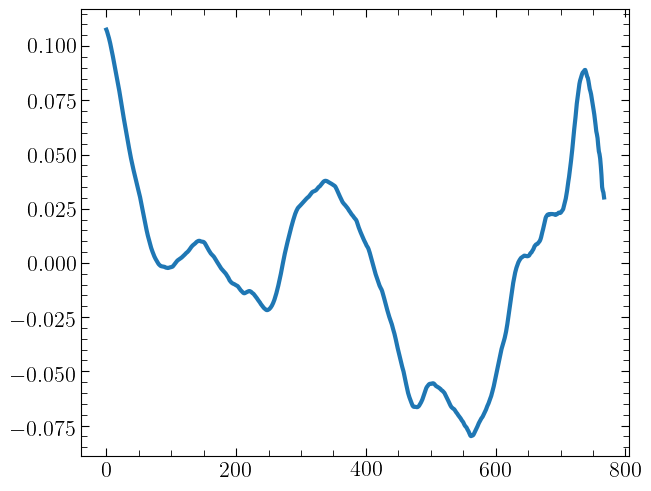

In [193]:
plt.plot(cl)

In [194]:
# import numpy as np

# def generate_1d_field_from_P(k_fun, N=2048, L=2*np.pi):
#     """
#     k_fun: function that returns P_cont(k) for array k
#     N:     number of grid points
#     L:     box length
#     """
#     dx = L / N
#     k = 2*np.pi * np.fft.fftfreq(N, d=dx)   # physical k array
#     kabs = np.abs(k)

#     # continuous power spectrum on this grid
#     P_cont = k_fun(kabs)
#     P_cont[0] = 0.0   # handle k=0 safely if needed

#     # convert to discrete FFT variance
#     Pk_dft = (N**2 / L) * P_cont

#     # allocate Fourier coefficients
#     fk = np.zeros(N, dtype=complex)

#     # k=0
#     fk[0] = np.sqrt(Pk_dft[0]) * np.random.randn()

#     # Nyquist (if even)
#     if N % 2 == 0:
#         ny = N//2
#         fk[ny] = np.sqrt(Pk_dft[ny]) * np.random.randn()

#     # positive frequencies
#     kmax = N//2 if N % 2 == 0 else (N-1)//2
#     for i in range(1, kmax):
#         a, b = np.random.randn(), np.random.randn()
#         amp = np.sqrt(Pk_dft[i] / 2.0)
#         fk[i] = amp * (a + 1j*b)
#         fk[-i] = fk[i].conjugate()

#     # inverse FFT → real field
#     field = np.fft.ifft(fk).real
#     return field, k, P_cont

# # Example: P(k) = k^-n
# n = 2.0
# L=2*np.pi
# k_fun = lambda kk: np.where(kk == 0, 0.0, kk**(-n))

# field, k, P_theory = generate_1d_field_from_P(k_fun)

# # Recover power spectrum from the realization:
# fk = np.fft.fft(field)
# P_rec = (L / field.size**2) * np.abs(fk)**2   # unbiased estimate of P_cont


In [195]:
# linear binning 

NB = 16
pkssq_re = np.zeros((Nrea, NB))
pks2p_re = np.zeros((Nrea, NB))

kval, _ = pfunc.get_model_pk(kp, kpara1, KK, PK)

k_cut = np.maximum(kpara[1], kp)
k_cut = -0.1
idx = np.where(kpara1 > k_cut)[0][0]
print(k_cut, idx)

for ii in range(Nrea):
    pkssq_re[ii], _, _ = pfunc.bin_array(pksq_arr[ii, idx:], NB, kval[idx:], log=False) # False, True
    pks2p_re[ii], _, _ = pfunc.bin_array(pk2p_arr[ii, idx:], NB, kval[idx:], log=False)

pksqa = np.mean(pkssq_re, axis=0)
pksqe = np.std(pkssq_re, axis=0)/np.sqrt(Nrea)

pka = np.mean(pks2p_re, axis=0)
pke = np.std(pks2p_re, axis=0)/np.sqrt(Nrea)

pks_th, kk, num = pfunc.bin_array(PKm[idx:], NB, kval[idx:], log=False)  


-0.1 0


In [196]:
(pka/pks_th) 

array([9.75022471e+07, 2.16161522e+08, 2.23240688e+08, 2.16476296e+08,
       1.94460119e+08, 2.32638248e+08, 2.22404980e+08, 2.30809527e+08,
       2.27316004e+08, 2.44981151e+08, 2.20435880e+08, 2.46467634e+08,
       2.42904434e+08, 2.08671924e+08, 2.14779150e+08, 2.47758993e+08])

/tmp/ipykernel_23460/2361025760.py:65: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  plt.tight_layout()


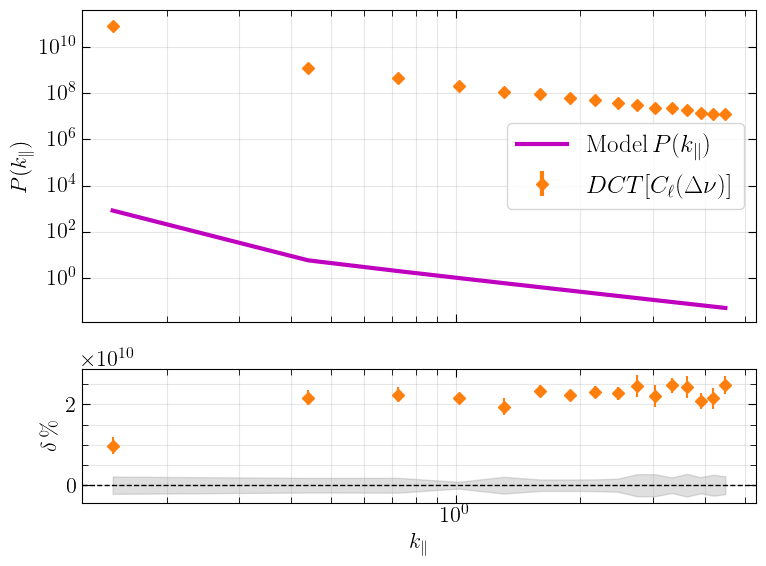

In [197]:
def dev_percent(P, Pm):
    return 100.0 * (P - Pm) / Pm


fig, axs = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1.5]}
)

# ---------------------------
# Top panel
# ---------------------------
axs[0].plot(kk, pks_th, color='m',
            label=r"${\rm Model} \, P(k_\parallel)$")

# # |V(tau)|^2  (delay estimator)
# axs[0].errorbar(kk, (pksqa), pksqe, ls='',
#                 color='C0', errorevery=1,marker='o',
#                 label=r"$|V(\tau)|^2$")

# Cℓ(Δν) → P(k)
axs[0].errorbar(kk, abs(pka), pke, ls='',
                color='C1', errorevery=1,marker='D',
                label=r"$DCT [ C_\ell(\Delta\nu) ]$")

axs[0].set_ylabel(r"$P(k_\parallel)$ ")
# axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True, which='both', alpha=0.3)


# deviation
dev_pk    = dev_percent(pka, pks_th)
dev_pksq  = dev_percent(pksqa, pks_th)

# deviation std
std_dev_pk   = 100 * pke   / pks_th
std_dev_pksq = 100 * pksqe / pks_th

err_band = np.maximum(std_dev_pk, std_dev_pksq)

axs[1].fill_between(kk,
                    -err_band, +err_band,
                    color='gray', alpha=0.25, 
                    label=r"$\pm1\sigma$ deviation")

# axs[1].errorbar(kk, dev_pksq, std_dev_pksq, ls='', marker='o',  errorevery=1,
#                 color='C0', label="Delay estimator", lw=1.5)

axs[1].errorbar(kk, dev_pk, std_dev_pk, ls='', marker='D',  errorevery=1,
                color='C1', label="Covariance estimator", lw=1.5)

axs[1].axhline(0, color='k', ls='--', lw=1)
axs[1].set_xlabel(r"$k_{\parallel}$")
axs[1].set_ylabel(r"$\delta \,\%$")
# axs[1].set_ylim(-10, 10)
# axs[1].legend()
axs[1].set_xscale('log')
# axs[1].set_yscale('symlog', linthreshy=50)
axs[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


In [184]:
# NB = 16
# pksq_re = np.zeros((Nrea, NB))
# pk_re = np.zeros((Nrea, NB))

# kval, PKm = pfunc.get_model_pk(kp, kpara1, KK, PK)

# k_cut = np.maximum(kpara[1], kp)
# # k_cut = -0.1
# idx = np.where(kpara1 > k_cut)[0][0]
# print(k_cut, idx)

# for ii in range(Nrea):
#     pk_re[ii], _, _ = pfunc.bin_array(pk_arr[ii, idx:], NB, kval[idx:], log=False) # False, True
#     pksq_re[ii], _, _ = pfunc.bin_array(PKsq_arr[ii, idx:], NB, kval[idx:], log=False)
    
# PKM, kk, num = pfunc.bin_array(PKm[idx:], NB, kval[idx:], log=False)  


In [185]:
num

array([50, 47, 48, 48, 48, 48, 48, 48, 47, 48, 48, 48, 48, 48, 48, 48])

In [186]:
# PKM = Pk_sph
# kk = k_sph

In [187]:
pksqa = np.mean(pksq_re, axis=0)
pksqe = np.std(pksq_re, axis=0)/np.sqrt(Nrea)

pka = np.mean(pk_re, axis=0)
pke = np.std(pk_re, axis=0)/np.sqrt(Nrea)



NameError: name 'pksq_re' is not defined

NameError: name 'PKM' is not defined

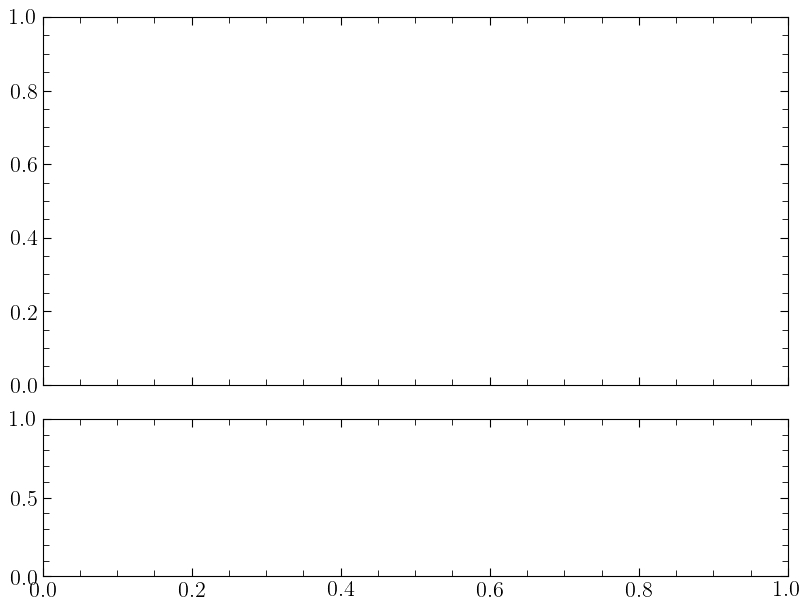

In [188]:
def dev_percent(P, Pm):
    return 100.0 * (P - Pm) / Pm


fig, axs = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1.5]}
)

# ---------------------------
# Top panel
# ---------------------------
axs[0].plot(kk, PKM, color='m',
            label=r"Model $P(k_\parallel)$")

# |V(tau)|^2  (delay estimator)
axs[0].errorbar(kk, (pksqa), pksqe, ls='',
                color='C0', errorevery=1,marker='o',
                label=r"$|V(\tau)|^2$")

# Cℓ(Δν) → P(k)
axs[0].errorbar(kk, abs(pka), pke, ls='',
                color='C1', errorevery=1,marker='D',
                label=r"$DCT [ C_\ell(\Delta\nu) ]$")

axs[0].set_ylabel(r"$P(k_\parallel)$ ")
# axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True, which='both', alpha=0.3)


# deviation
dev_pk    = dev_percent(pka, PKM)
dev_pksq  = dev_percent(pksqa, PKM)

# deviation std
std_dev_pk   = 100 * pke   / PKM
std_dev_pksq = 100 * pksqe / PKM

err_band = np.maximum(std_dev_pk, std_dev_pksq)

axs[1].fill_between(kk,
                    -err_band, +err_band,
                    color='gray', alpha=0.25, 
                    label=r"$\pm1\sigma$ deviation")

# axs[1].errorbar(kk, dev_pksq, std_dev_pksq, ls='', marker='o',  errorevery=1,
#                 color='C0', label="Delay estimator", lw=1.5)

axs[1].errorbar(kk, dev_pk, std_dev_pk, ls='', marker='D',  errorevery=1,
                color='C1', label="Covariance estimator", lw=1.5)

axs[1].axhline(0, color='k', ls='--', lw=1)
axs[1].set_xlabel(r"$k$")
axs[1].set_ylabel(r"$\delta \,\%$")
axs[1].set_ylim(-50, 50)
# axs[1].legend()
# axs[1].set_xscale('log')
# axs[1].set_yscale('symlog', linthreshy=50)
axs[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
kp

In [203]:
import numpy as np

def gaussian_field_1d_from_Pk_cont(k_grid, Pk_cont, N, L):
    """
    Generate a 1D real Gaussian random field with a given *continuous* power spectrum Pk_cont(k).

    Parameters
    ----------
    k_grid   : 1D array
        k values (same units as you want for k_parallel) on which Pk_cont is defined.
    Pk_cont  : 1D array
        Continuous power spectrum P(k) evaluated on k_grid.
    N        : int
        Number of samples in the field (e.g. N = nc1).
    L        : float
        Physical length of the domain along the LOS (same units as r * Δν).

    Returns
    -------
    field : 1D ndarray (real)
        Real-space field with the desired power spectrum (in the ensemble average).
    k_fft : 1D ndarray
        k values corresponding to the FFT modes of this field.
    Pk_cont_fft : 1D ndarray
        P_cont(k) evaluated on k_fft (the grid actually used).
    """
    # grid spacing in "distance" (e.g. r * Δν)
    dx = L / N

    # FFT k-grid (can be negative; use absolute value for interpolation)
    k_fft = 2.0 * np.pi * np.fft.fftfreq(N, d=dx)
    k_abs = np.abs(k_fft)

    # interpolate the input P(k) onto the FFT k-grid
    Pk_cont_fft = np.interp(k_abs, k_grid, Pk_cont, left=0.0, right=0.0)

    # convert continuous P(k) to discrete variance of FFT coefficients
    # < |f_k|^2 >_DFT = (N^2 / L) * P_cont(k)
    Pk_dft = (N**2 / L) * Pk_cont_fft

    # allocate Fourier coefficients
    fk = np.zeros(N, dtype=np.complex128)

    # k = 0 mode (real)
    fk[0] = np.sqrt(Pk_dft[0]) * np.random.randn()

    # Nyquist (if even, real)
    if N % 2 == 0:
        ny = N // 2
        fk[ny] = np.sqrt(Pk_dft[ny]) * np.random.randn()

    # positive frequencies (1 ... kmax-1) and their conjugates
    kmax = N // 2 if N % 2 == 0 else (N - 1) // 2 + 1
    for i in range(1, kmax):
        a, b = np.random.randn(), np.random.randn()
        amp = np.sqrt(Pk_dft[i] / 2.0)
        fk[i]  = amp * (a + 1j * b)
        fk[-i] = fk[i].conjugate()

    # inverse FFT -> real field
    field = np.fft.ifft(fk).real
    return field, k_fft, Pk_cont_fft

# --- geometry / grids ---
Nrea = 10          # number of realizations

nc1 = np.argmax(ml.real == 0) if np.any(ml.real == 0) else nc
N   = nc1

# physical LOS length in comoving units
# choose the convention that matches how you defined PKm2D
L_los = (N * dnuc) * rp    # or rp * (2*N - 2) * dnuc if that is what PKm uses

# k_parallel grid on which your model PKm2D is defined:
# (adapt this to whatever you actually used when building PKm2D)
kpara_model = kpara1[:N]   # if kpara1 matches the PKm2D grid


nl = 0
kp = kper[nl]          # fixed k_perp slice
Pk_model_1d = PKm2D[nl, :N]   # take only the first N = nc1 elements


pk2p_arr = np.zeros((Nrea, N))

w = windows.nuttall(2*N)[N:]  # same window you had before, now N = nc1

for i in range(Nrea):

    # --- Generate 1D Gaussian field along ν for this (k_perp = kp) ---
    VX, k_fft, Pk_used = gaussian_field_1d_from_Pk_cont(
        k_grid   = kpara_model,
        Pk_cont  = Pk_model_1d,
        N        = N,
        L        = L_los
    )

    # you can use same field for X and Y, or different realizations
    VY = VX.copy()

    # --- MAPS -> C_ell estimator ---
    el = pfunc.covtocl_fast(VY, VX)
    cl = el / ml

    # --- DCT to go from C(Δν) to P(k_parallel) ---
    # here cl[:N] corresponds to separations 0..(N-1)
    pk_dct = dct(cl[:N] * w[:N], type=1) * (N - 1) / 2.0

    # --- Convert this DCT quantity into continuous P(k_parallel) ---
    # The DCT kernel plus your derivation should tell you the exact factor.
    # If your derivation gave:
    #   P_cont(k) = fact * pk_dct
    # then *fact* should be = L_los / N**2 to be consistent with the FFT math.
    fact = L_los / (N**2)

    pk2p_arr[i] = pk_dct * fact


/tmp/ipykernel_23460/851495215.py:116: ComplexWarning: Casting complex values to real discards the imaginary part
  pk2p_arr[i] = pk_dct * fact


In [204]:
NB = 16
k_cut = 0.0  # or your choice: avoid k=0 divergence if needed
idx = np.where(np.abs(k_fft) > k_cut)[0][0]  # same threshold

# --- recovered spectra (averaged over realizations) ---
binned_rec = []
for i in range(Nrea):
    binned, kval_bin, counts = pfunc.bin_array(pk2p_arr[i, idx:], NB, np.abs(k_fft[idx:]), log=False)
    binned_rec.append(binned)

binned_rec = np.array(binned_rec)
pka = np.mean(binned_rec, axis=0)
pke = np.std(binned_rec, axis=0) / np.sqrt(Nrea)


In [211]:
# --- interpolate model to FFT k-grid (already matched by gaussian_field_1d_from_Pk_cont) ---
Pk_th_fft = Pk_used.copy()   # already on FFT grid

# --- apply window convolution effect ---
Pk_th_windowed = Pk_th_fft 

# --- bin theory like recovered ---
pks_th, kval_bin, _ = pfunc.bin_array(Pk_th_windowed[idx:], NB, np.abs(k_fft[idx:]), log=False)


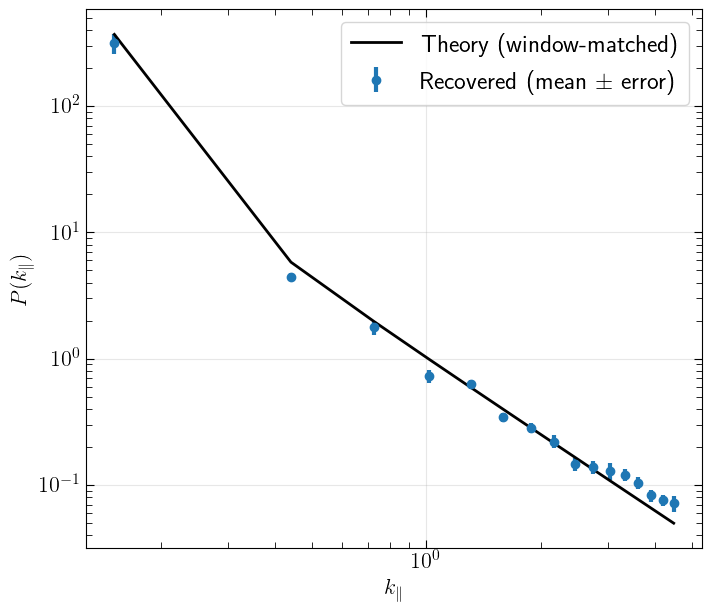

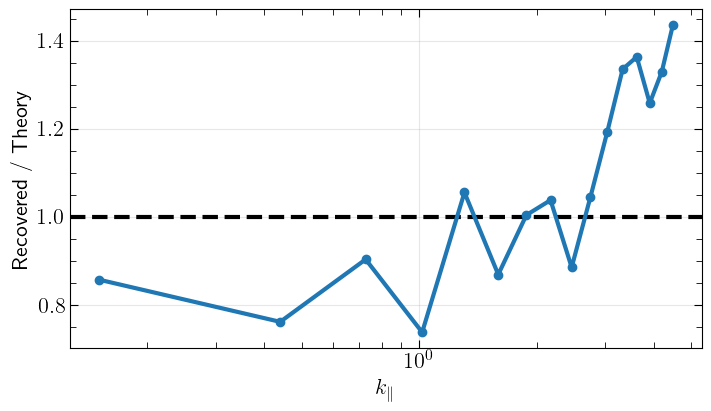

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# recovered
plt.errorbar(kval_bin, pka, pke, fmt='o', label='Recovered (mean ± error)')

# theory
plt.plot(kval_bin, pks_th, '-k', lw=2, label='Theory (window-matched)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel(r'$P(k_\parallel)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# --- OPTIONAL sanity: theory / recovered ratio ---
plt.figure(figsize=(7,4))
plt.axhline(1.0, color='k', ls='--')
plt.plot(kval_bin, pka/pks_th, 'o-')
plt.xscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel('Recovered / Theory')
plt.grid(alpha=0.3)
plt.show()
